In [1]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error


/tmp/ipykernel_17126/4252564045.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)


In [3]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",")
pd.set_option('display.max_columns', None)


In [4]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


In [5]:
# ================ #
# 5. PREPROCESADOR #
# ================ #

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', features)
])


In [6]:
# =============================== #
# VISUALIZAR EL PRE-PROCESAMIENTO #
# =============================== #

preprocessor


ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['job_title', 'education_level', 'industry',
                                  'company_size', 'location', 'remote_work']),
                                ('num', 'passthrough',
                                 ['experience_years', 'skills_count',
                                  'certifications'])])

In [7]:
# ========================= #
# 6. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [8]:
# =========== #
# 7. MODELO XGBOOST #
# =========== #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', 'passthrough',
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [9]:
# ============== #
# 8. EVALUACIÓN  #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)


MAE: 4660.210796458333
RMSE: 5904.574198851468
MAPE: 0.033857437854963306
MAPE(%): 3.3857437854963304
R2: 0.9749821424484253


In [10]:
# ======================================== #
# 8.1. DATAFRAME CON RESULTADOS Y ERRORES  #
# ======================================== #

X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df
df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)


,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
37469,13,10,0,Data Analyst,High School,Finance,Enterprise,Netherlands,Hybrid,120313,125252.265625,-4939.265625,4939.265625
69983,6,18,2,Cloud Engineer,Diploma,Telecom,Enterprise,India,No,107530,108855.804688,-1325.804688,1325.804688
17436,20,8,1,Software Engineer,Bachelor,Healthcare,Startup,Australia,Yes,142104,138496.390625,3607.609375,3607.609375
4259,17,16,1,Product Manager,High School,Government,Medium,Singapore,Yes,158174,158114.687500,59.312500,59.312500
68782,7,17,3,Software Engineer,Master,Media,Large,Sweden,No,148977,149442.515625,-465.515625,465.515625
62971,9,6,5,Business Analyst,PhD,Finance,Small,Canada,Yes,152040,147948.640625,4091.359375,4091.359375
1214,12,11,2,Product Manager,Bachelor,Retail,Large,India,No,110164,112560.976562,-2396.976562,2396.976562
63194,1,9,2,DevOps Engineer,Master,Retail,Startup,Germany,Yes,128295,125974.781250,2320.218750,2320.218750
27130,7,19,2,AI Engineer,Bachelor,Technology,Small,Australia,Hybrid,145519,147001.046875,-1482.046875,1482.046875
33649,16,16,1,Data Scientist,Master,Finance,Small,Netherlands,Hybrid,158498,151519.718750,6978.281250,6978.281250


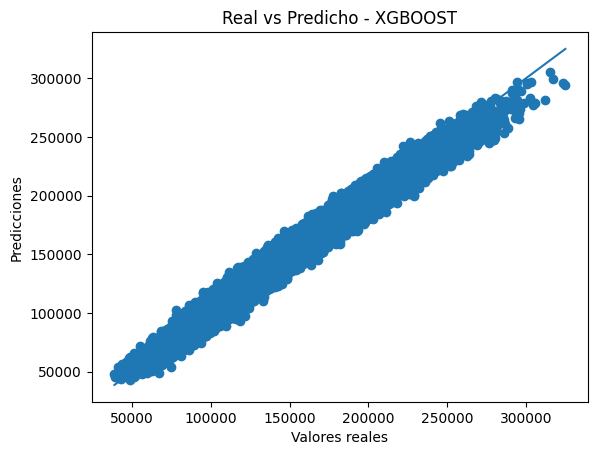

In [11]:
# ====================== #
# 8.2. REAL VS PREDICHO  #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho - XGBOOST")
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)
plt.show()


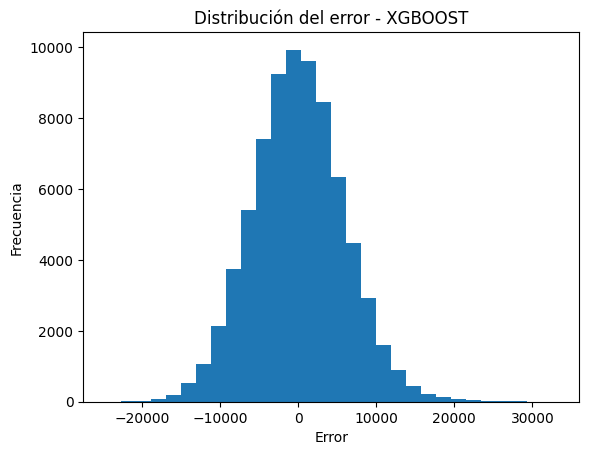

In [12]:
# ============================= #
# 8.3. DISTRIBUCIÓN DE ERRORES  #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error - XGBOOST")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()
